## Agentic RAG with Langchain v1, Ollama, and FAISS
**Key Features:**
- Agent-based architecture with autonomous tool usage for document retrieval
- FAISS vector store for efficient semantic search across document embeddings
- Ollama integration with Qwen3 LLM and nomic-embed-text embeddings for local deployment
- Custom retrieval tool that finds and formats relevant document chunks with metadata
- Interactive chat interface with streaming responses and tool call visibility

In [1]:
# pip install -U langchain langchain-ollama, langchain-community langchain-core faiss-cpu
# ollama pull nomic-embed-text
# ollama pull qwen3

In [2]:
import os
import warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
warnings.filterwarnings("ignore")

from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv


load_dotenv()

True

In [3]:
# ============================================================================
# LLM & VECTOR STORE SETUP
# ============================================================================
# Ollama LLM with Qwen3
llm = ChatOllama(
    model="qwen3", 
    base_url="http://localhost:11434"
)

# Ollama Embeddings
embeddings = OllamaEmbeddings(
    model="nomic-embed-text",
    base_url="http://localhost:11434"
)

# FAISS Vector Store (assumes data already exists from previous code)
db_name = "./../09. Vector Stores and Retrievals/health_supplements"
vector_store = FAISS.load_local(
    db_name,
    embeddings,
    allow_dangerous_deserialization=True
)

In [4]:
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-03-25T15:35:59.3621917Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6132741200, 'load_duration': 5207122800, 'prompt_eval_count': 11, 'prompt_eval_duration': 48413700, 'eval_count': 93, 'eval_duration': 807059800, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019d25a3-5060-7e52-afa7-44287922b994-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 93, 'total_tokens': 104})

In [5]:
# ============================================================================
# VECTOR STORE VERIFICATION
# ============================================================================
print("\n🔍 Testing Vector Store Connection...")

# Test 1: Check collection info
doc_count = vector_store.index.ntotal
print(f"✓ Vector store found with {doc_count} documents")


# Test 2: Sample similarity search
test_query = "creatine"
results = vector_store.similarity_search(test_query, k=3)
print(f"\n✓ Sample search for '{test_query}':")
for i, doc in enumerate(results, 1):
    print(f"  {i}. Source: {doc.metadata.get('source', '?')} (Page {doc.metadata.get('page', '?')}): {doc.page_content[:100]}...")




🔍 Testing Vector Store Connection...
✓ Vector store found with 6823 documents

✓ Sample search for 'creatine':
  1. Source: rag-dataset\gym supplements\1. Analysis of Actual Fitness Supplement.pdf (Page 1): Foods 2024, 13, 1424
2 of 21
and sports industry, evidence suggests that creatine can benefit not on...
  2. Source: rag-dataset\gym supplements\2. High Prevalence of Supplement Intake.pdf (Page 10): supplements such as creatine or beta-alanine were used only once a week, which cannot be eﬀective [9...
  3. Source: rag-dataset\gym supplements\2. High Prevalence of Supplement Intake.pdf (Page 8): and strength gain among men. We detected more prevalent protein and creatine supplementation
among y...


In [6]:
results

[Document(id='0ef3d559-b571-4ed0-9f90-dcca4ca889d6', metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '', 'source': 'rag-dataset\\gym supplements\\1. Analysis of Actual Fitness Supplement.pdf', 'file_path': 'rag-dataset\\gym supplements\\1. Analysis of Actual Fitness Supplement.pdf', 'total_pages': 15, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-10-21T11:38:50+00:00', 'trapped': '', 'modDate': 'D:20241021113850Z', 'creationDate': '', 'page': 1}, page_content='Foods 2024, 13, 1424\n2 of 21\nand sports industry, evidence suggests that creatine can benefit not only athletes but also\nthe elderly and the general population [6]. Branched-chain amino acids (BCAA) also offer\na plethora of benefits for consumers. As explained by Sanz et al. [7], BCAAs are stored\ndirectly in muscles and serve as the raw materials needed to build new muscle. This\ncontributes to the overall process of strengthening muscles and alleviating post

In [7]:
# ============================================================================
# RETRIEVAL TOOL
# ============================================================================
@tool()
def retrieve_context(query: str):
    """Retrieve relevant information for health related queries from the document to answer the query.
    
    """
    print(f"🔍 Searching: '{query}'")
    
    # Perform similarity search
    docs = vector_store.similarity_search(query, k=4)
    
    # Format for LLM
    content = "\n\n".join(
        f"Source: {doc.metadata.get('source', '?')} (Page {doc.metadata.get('page', '?')}): {doc.page_content}"
        for doc in docs
    )
    
    print(f"✓ Found {len(docs)} relevant chunks")
    return content


In [8]:
result = retrieve_context.invoke("What is the use of BCAA?")
# print(result)

🔍 Searching: 'What is the use of BCAA?'
✓ Found 4 relevant chunks


#### Create Tools and Agent

In [9]:
tools = [retrieve_context]

system_prompt = """You are a research assistant with a document retrieval tool.

                    Tool:
                    - retrieve_context: Search the document for the health related question

                    Cite page numbers and reference document while writing the answer and be thorough."""

In [10]:
# Create the agentic RAG
rag_agent = create_agent(llm, tools, system_prompt=system_prompt)

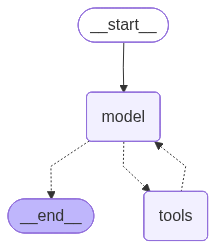

In [11]:
rag_agent

In [12]:
result = rag_agent.invoke({'messages': "What is the use of BCAA?"})

🔍 Searching: 'use of BCAA'
✓ Found 4 relevant chunks


In [13]:
result

{'messages': [HumanMessage(content='What is the use of BCAA?', additional_kwargs={}, response_metadata={}, id='ed9a8749-1470-4f90-9d60-75b30853bbdf'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-03-25T15:37:46.6252165Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2785959300, 'load_duration': 83999000, 'prompt_eval_count': 191, 'prompt_eval_duration': 199063500, 'eval_count': 267, 'eval_duration': 2397393900, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019d25a5-009d-7a42-a244-7331316a95b2-0', tool_calls=[{'name': 'retrieve_context', 'args': {'query': 'use of BCAA'}, 'id': 'b9dce4a5-d605-4457-9057-6f5c5080dd05', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 191, 'output_tokens': 267, 'total_tokens': 458}),
  ToolMessage(content='Source: rag-dataset\\finance\\pdfs\\meta\\meta 10-q q1 2024.pdf (Page 13): Appendix\n\nSource: rag-dataset\\finance\\pdfs\

In [14]:
result['messages'][-1].pretty_print()

================================== Ai Message ==================================

The retrieved documents from Meta's financial filings (10-Q reports) do not discuss the use of BCAA (Branched-Chain Amino Acids). These documents focus on financial metrics, quarterly performance, and corporate disclosures, not health or nutritional information. 

For context on BCAA usage, general knowledge indicates that BCAA are amino acids (leucine, isoleucine, valine) often used in sports nutrition to support muscle protein synthesis, reduce exercise fatigue, and aid recovery. However, this information is not derived from the provided sources. 

If you need health-related details about BCAA, consult scientific studies or medical resources. The cited documents (Pages 13 of Appendices in the 10-Q filings) are unrelated to this topic.


In [15]:
# ============================================================================
# QUERY FUNCTION
# ============================================================================
# This function allows us to ask questions to the agentic RAG and see the tool usage and final answer in a clear format.
def ask(question: str):
    """Ask the agentic RAG a question."""
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print('='*60)
    
    for event in rag_agent.stream(
        {"messages": [{"role": "user", "content": question}]},
        stream_mode="values"
    ):
        msg = event["messages"][-1]
        
        # Show tool usage
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tc in msg.tool_calls:
                print("Tool Call: ")
                print(f"\n🔧 Using: {tc['name']} with {tc['args']}")
        
        # Show final answer
        elif hasattr(msg, 'content') and msg.content:
            print(f"\n💬 Answer:\n{msg.content}")

In [16]:
# ============================================================================
# TESTING
# ============================================================================
# Test basic retrieval
ask("how to gain muscle mass?")



Question: how to gain muscle mass?

💬 Answer:
how to gain muscle mass?
Tool Call: 

🔧 Using: retrieve_context with {'query': 'how to gain muscle mass?'}
🔍 Searching: 'how to gain muscle mass?'
✓ Found 4 relevant chunks

💬 Answer:
Source: rag-dataset\gym supplements\2. High Prevalence of Supplement Intake.pdf (Page 8): and strength gain among men. We detected more prevalent protein and creatine supplementation
among younger compared to older ﬁtness center users, whereas the opposite was found for vitamin
supplementation. Other authors made similar observations [23] and it might reﬂect the diﬀerent
training goals among age groups, i.e., more focus on strength and muscles among the younger and
more focus on health among the older age groups.
Comparable to other studies [4], we detected a positive correlation between training frequency
and supplement usage. Nevertheless, the correlation is weak and is deﬁnitely not a predictor at the
individual level. The subject with the highest suppleme

In [29]:
ask("tell me 3 facts about Earth?")


Question: tell me 3 facts about Earth?

💬 Answer:
tell me 3 facts about Earth?

💬 Answer:
The query about Earth is not related to health, so I cannot use the provided tool to retrieve information. Here are three general facts about Earth:

1. **Third Planet from the Sun**: Earth is the third planet in our solar system and the only known celestial body to support life.  
2. **Unique Atmosphere**: Its atmosphere, rich in nitrogen and oxygen, along with the presence of liquid water, creates conditions suitable for life.  
3. **Dynamic Geology**: Earth is geologically active, with processes like plate tectonics, volcanism, and erosion shaping its surface over time.  

Let me know if you'd like health-related information!


In [17]:
# ============================================================================
# INTERACTIVE CHAT
# ============================================================================
def chat():
    """Start interactive chat with the agentic RAG."""
    print("\n🤖 Agentic RAG Chat - Type 'quit, q or exit' to exit")
    
    while True:
        question = input("\nYour question: ").strip()
        if question.lower() in ['quit', 'exit', 'q']:
            break
        if question:
            ask(question)

chat()


🤖 Agentic RAG Chat - Type 'quit, q or exit' to exit

Question: creatine

💬 Answer:
creatine
Tool Call: 

🔧 Using: retrieve_context with {'query': 'creatine'}
🔍 Searching: 'creatine'
✓ Found 4 relevant chunks

💬 Answer:
Source: rag-dataset\gym supplements\1. Analysis of Actual Fitness Supplement.pdf (Page 1): Foods 2024, 13, 1424
2 of 21
and sports industry, evidence suggests that creatine can benefit not only athletes but also
the elderly and the general population [6]. Branched-chain amino acids (BCAA) also offer
a plethora of benefits for consumers. As explained by Sanz et al. [7], BCAAs are stored
directly in muscles and serve as the raw materials needed to build new muscle. This
contributes to the overall process of strengthening muscles and alleviating post-workout
soreness. Consumers often integrate these supplements into their routines with the aim of
optimizing the outcomes they wish to achieve and support overall well-being [1].
The sports supplement industry makes for an imp